<a href="https://colab.research.google.com/github/oxcracx/ml-learn/blob/main/linear_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*DAY 02 : Using Linear Regression - ML *

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model #Hey, I am using skylearn, an adv python ml library.

df = pd.read_csv("/content/canada_per_capita_income.csv")

In [21]:
df

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


* I made a mistake while typing the name to represent y, I wrote "per capita income" instead of writing "per capita income (US$)" ha ha ha.. silly me :(

"%matplotlib inline" displays plots inside the notebook

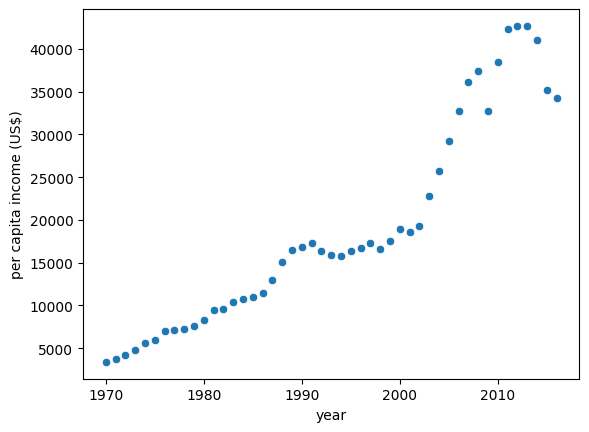

In [22]:
%matplotlib inline
sns.scatterplot(x=df["year"], y=df["per capita income (US$)"])
plt.show()

To get the better understanding of data, i am using color like red and marker as +

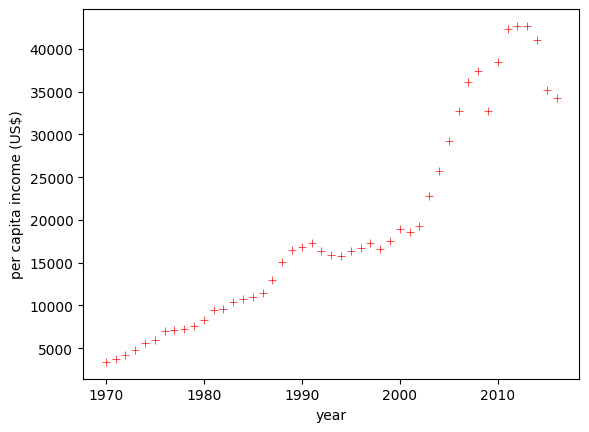

In [58]:
%matplotlib inline
sns.scatterplot(x=df["year"], y=df["per capita income (US$)"], color='red', marker='+')
plt.show()

Here in the reg model, "fit" means training the model with the available dataset.

In [26]:
reg = linear_model.LinearRegression()
reg.fit(df[["year"]], df["per capita income (US$)"])

LinearRegression()

I had also use reg.predict(2020), but it was throwing warning which was not wrong but for the best practice pd is used more.

In [39]:
reg.predict(pd.DataFrame([[2025]], columns=['year']))

array([45431.01947053])

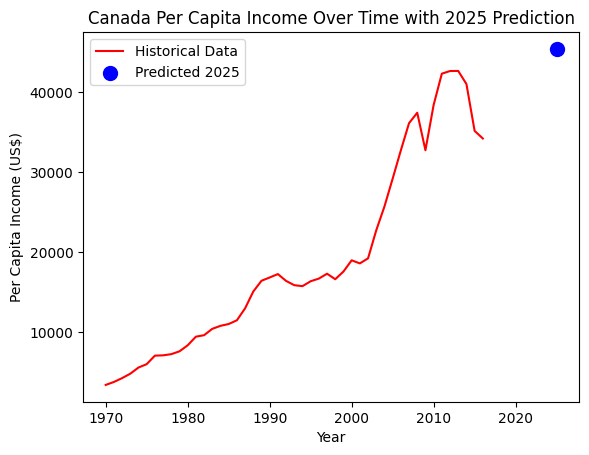

In [57]:
%matplotlib inline
sns.lineplot(x=df["year"], y=df["per capita income (US$)"], color='red', label='Historical Data')
plt.scatter(2025, reg.predict(pd.DataFrame([[2025]], columns=['year'])), color='blue', marker='o', s=100, label='Predicted 2025')
plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.title('Canada Per Capita Income Over Time with 2025 Prediction')
plt.legend()
plt.show()

In [56]:
# years from 2017 to 2025
future_years = pd.DataFrame({'year': np.arange(2017, 2026)})

predicted_income_future = reg.predict(future_years)

# DataFrame to display the results
predictions_future_df = pd.DataFrame({'year': future_years['year'], 'predicted per capita income (US$)': predicted_income_future})

display(predictions_future_df)

,year,predicted per capita income (US$)
0,2017,38803.298869
1,2018,39631.763944
2,2019,40460.229019
3,2020,41288.694094
4,2021,42117.159170
5,2022,42945.624245
6,2023,43774.089320
7,2024,44602.554395
8,2025,45431.019471


To know why the certain outcome, we have know the internal details... (optional)

In [42]:
reg.coef_ #based on formula, y(per cap income) = m * x(year) + b

array([828.46507522])

In [41]:
reg.intercept_

np.float64(-1632210.7578554575)

In [43]:
# so according to the formula y  = m * x + b
828.46507522*2025+(-1632210.7578554575)

45431.01946504251